Best Solution: [ 0.34730987  0.01236644 -0.16767698  0.23136883 -0.40598301]
Best Fitness: 0.3672463869366309


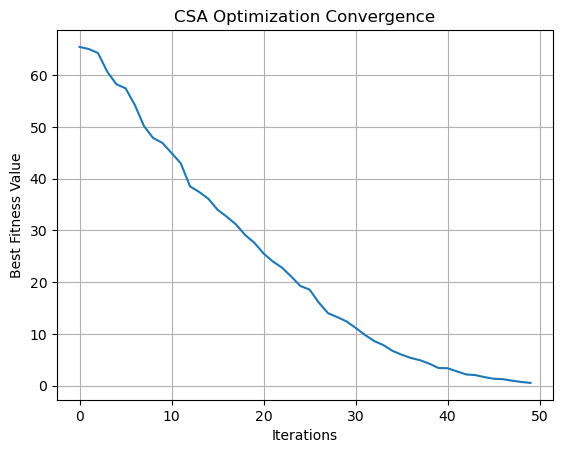

In [3]:
# -------------------------------
# Imports
# -------------------------------
import numpy as np
import matplotlib.pyplot as plt

# ✅ FIX: Set seed for same output
np.random.seed(42)

# -------------------------------
# Fitness Function
# -------------------------------
def fitness_function(x):
    return np.sum(x ** 2)

# -------------------------------
# Parameters
# -------------------------------
population_size = 20
dimensions = 5
clone_factor = 5
mutation_rate = 0.1
iterations = 50
bounds = (-10, 10)

# -------------------------------
# Initialize Population
# -------------------------------
def initialize_population():
    return np.random.uniform(bounds[0], bounds[1], (population_size, dimensions))

# -------------------------------
# Clonal Selection Algorithm
# -------------------------------
def clonal_selection():

    population = initialize_population()
    best_fitness_history = []

    for iteration in range(iterations):

        fitness = np.array([fitness_function(ind) for ind in population])

        sorted_indices = np.argsort(fitness)
        population = population[sorted_indices]
        fitness = fitness[sorted_indices]

        best_fitness_history.append(fitness[0])

        selected = population[:population_size // 2]

        clones = []
        for antibody in selected:
            for _ in range(clone_factor):
                clone = antibody + mutation_rate * np.random.randn(dimensions)
                clone = np.clip(clone, bounds[0], bounds[1])
                clones.append(clone)

        clones = np.array(clones)

        clone_fitness = np.array([fitness_function(c) for c in clones])

        combined_population = np.vstack((population, clones))
        combined_fitness = np.hstack((fitness, clone_fitness))

        best_indices = np.argsort(combined_fitness)[:population_size]
        population = combined_population[best_indices]

    return population[0], best_fitness_history

# -------------------------------
# Run Algorithm
# -------------------------------
best_solution, fitness_history = clonal_selection()

print("Best Solution:", best_solution)
print("Best Fitness:", fitness_function(best_solution))

# -------------------------------
# Plot
# -------------------------------
plt.plot(fitness_history)
plt.xlabel("Iterations")
plt.ylabel("Best Fitness Value")
plt.title("CSA Optimization Convergence")
plt.grid()
plt.show()